# The fund that traded 40 % above its own bitcoin — then 49 % below — then exactly at it 🎁
### The GBTC premium cycle: one wrapper, three regimes, all mechanical — in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Who could harvest?: Mixed](https://img.shields.io/badge/Who_could_harvest%3F-Mixed-8b949e?style=flat-square)

From 2015 to 2024, one fund — Grayscale's GBTC — held nothing but bitcoin, and *still* managed to be spectacularly mispriced in **both directions**. For six years the shares cost up to **2.3× the bitcoin inside them**. Then for three years you could buy the same bitcoin at **half price** — and it kept getting cheaper. Then, on one dated, scheduled day in January 2024, the gap **vanished** and never came back.

No secret information, no genius. Every one of those three regimes was **mechanical** — built out of who was allowed to create shares, who was allowed to redeem them (nobody), and what happened when that changed.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the calibration residuals and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **One honest note up front.** The star trade of this story — buying the discount in 2023 — was real, big, and *is now permanently closed*. This is a teardown of a finished trade, not a tip. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gbtc_premium_cycle import data, strategy as st

HAVE_REAL = data.have_real()
DF = data.load_real(as_of=data.AS_OF) if HAVE_REAL else None
print("real GBTC/BTC cache present:", HAVE_REAL,
      "| rows:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2015-05-11', 'end': '2026-06-30', 'n_days': 2801, 'fingerprint': '5ffd3440484c', 'bps_split': 0.0010076, 'bps_conv': 0.00089442, 'regimes': [('premium era', '2015-05-11', '2021-02-22', 1457, 36.32, 8.97, 132.01, '2017-08-31'), ('discount era', '2021-02-23', '2024-01-10', 726, -24.49, -7.44, -48.8, '2022-12-13'), ('ETF era', '2024-01-11', '2026-06-30', 618, -0.03, -0.85, -4.11, '2026-04-07')], 'first_discount': '2021-02-26', 'welch_regimes': 80.23, 'etf_mean': -0.026, 'etf_sd': 0.915, 'etf_absmean': 0.638, 'conv_full': ('full 2023', 257, -45.95, -1.52, 59.99, 23.34, 1.92), 'conv_trig': ('ex-ante trigger', 143, -36.29, -1.52, 43.54, 30.45, 2.69), 'costs': [(10, 49.63), (25, 48.74), (50, 47.26)], 'legs_pct': 0.4, 'borrow_pct': 2.84, 'years': 0.57, 'events': [('2023-06-15', 'BlackRock files (after hours)', -0.73, -0.3), ('2023-06-16', 'first close after the filing', 9.19, 3.5), ('2023-08-29', 'Grayscale v. SEC ruling', 9.64, 3.7), ('2024-01-10', 'SEC approves spot ETFs', 2.72, 1.0), ('2024-01-11', 'first day as an ETF', 1.04, 0.4)], 'arb_early_n': 63, 'arb_early_mean': 26.49, 'arb_early_worst': -1.98, 'arb_early_pos': 98, 'arb_late_n': 10, 'arb_late_mean': -16.96, 'arb_late_worst': -23.03, 'arb_welch': 17.76, 'syn': [('premium + drift', 41.05, 3.37), ('premium, NO drift', 41.05, 0.29), ('null (prem ~ 0)', 0.75, 0.29)]}


real GBTC/BTC cache present: True | rows: 2801


## The answer first

| Question | Answer |
|---|---|
| Did GBTC really trade 40 % above its bitcoin? | **Yes.** From 2015 to early 2021 the premium averaged **+36 %**, peaking at **+132 %** in 2017. People paid double for wrapped bitcoin because a brokerage account couldn't hold the real thing. |
| And then 45 % below? | **Yes — worse.** From Feb-2021 the same shares flipped to a discount that bottomed at **−48.8 %** in December 2022. The coins were trapped: the trust had **no redemption mechanism**. |
| Did it really snap to zero when it became an ETF? | **Yes, to the basis point.** Since 2024-01-11 the gap averages **−0.03 %**. ETF market-makers can create *and redeem* at NAV, so any gap gets arbitraged away within hours. |
| Could *you* have made money on this? | **Only on one of the three legs.** The premium was harvestable only by accredited insiders (and it eventually bankrupted several of them). The **2023 discount convergence** was the public's leg: ~**+50 % net** in 7 months, hedged. Today: nothing left. |

> One wrapper, three regimes, three different sets of winners. All of it mechanical.

## 1 · The claim

> *"GBTC traded 40 % above its bitcoin, then 45 % below, then snapped to zero the day it became an ETF — one wrapper, three regimes, all mechanical."*

The mechanics in one breath: GBTC was a **trust**. New shares could be created — at fair value — **only by accredited investors**, who then had to hold them for a 6-to-12-month lockup before selling to the public. And **nobody** could ever redeem shares back into bitcoin. One-way in, no way out.

- While GBTC was the *only* bitcoin in a brokerage account → retail demand piled into a fixed public float → **premium**.
- Once futures, Canadian ETFs and rivals arrived → demand left, but the coins couldn't → **discount** (no redemption = no floor).
- The moment it converted to a real ETF (2024-01-11) → create **and redeem** at NAV → **zero**, forever.

## 2 · So what?

This is the cleanest live lesson in what actually pins a fund's price to its assets: **not fairness, not efficiency — the redemption arb**. Remove it and a fund holding the world's most liquid crypto asset can trade at *half* its value for years. Restore it and the gap dies in a day.

It also matters because each regime paid a *different* person. If you can't say **who** gets to do the arbitrage, you don't understand the price. That's the third axis of this study: who could actually harvest each regime?

## 3 · How would we even know?

GBTC publishes how much bitcoin backs each share — and it moves for known, boring reasons: a **2 %/yr fee** taken in bitcoin, a **91-for-1 split** in 2018, a fee cut at the ETF conversion, and a 2024 spin-off. So we can **rebuild the bitcoin-per-share for every day since 2015** from those public mechanics, multiply by the bitcoin price, and compare with what GBTC actually traded at.

Best of all, the model **grades itself**: after the ETF conversion the arbitrage forces the gap to ~0. If our reconstruction were off by even 1 %, the post-2024 'premium' would sit at a visible constant offset. It sits at **−0.03 %**. The ruler is straight.

## 4 · The teardown — let's actually look

**The whole life of the wrapper.** GBTC's premium/discount to its own bitcoin, every trading day from its 2015 OTC debut through today.

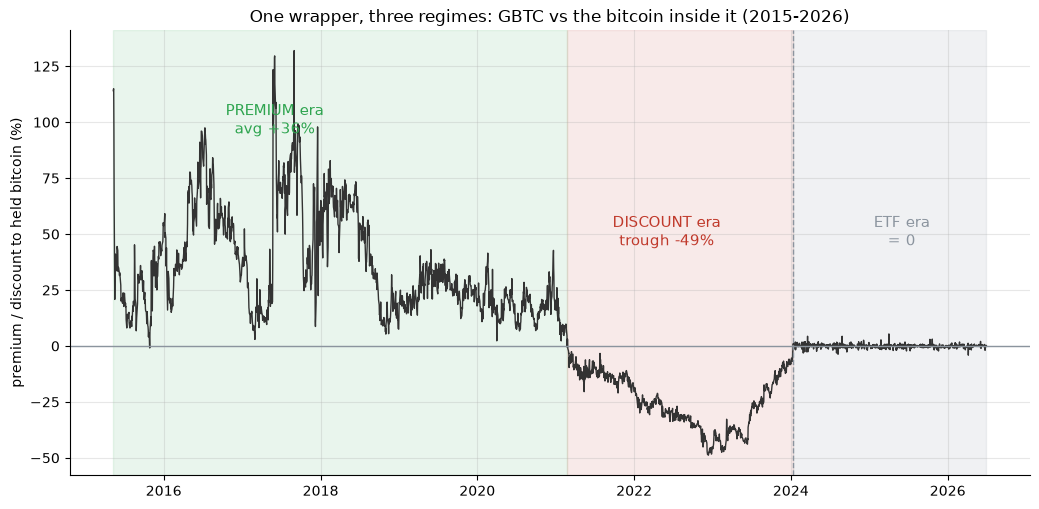

peak +132.0%  trough -48.8%  today +0.21%


In [2]:
if HAVE_REAL:
    prem = DF['prem'] * 100
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    ax.plot(prem.index, prem.values, lw=1.0, color='#333333')
    ax.axhline(0, c=GREY, lw=1)
    ax.axvspan(pd.Timestamp('2015-05-11'), pd.Timestamp('2021-02-22'), color=GREEN, alpha=.10)
    ax.axvspan(pd.Timestamp('2021-02-23'), pd.Timestamp('2024-01-10'), color=RED, alpha=.10)
    ax.axvspan(pd.Timestamp('2024-01-11'), prem.index[-1], color=GREY, alpha=.12)
    ax.annotate('PREMIUM era\navg +36%', (pd.Timestamp('2017-06-01'), 95), color=GREEN, fontsize=11, ha='center')
    ax.annotate('DISCOUNT era\ntrough -49%', (pd.Timestamp('2022-06-01'), 45), color=RED, fontsize=11, ha='center')
    ax.annotate('ETF era\n= 0', (pd.Timestamp('2025-06-01'), 45), color=GREY, fontsize=11, ha='center')
    ax.axvline(pd.Timestamp('2024-01-11'), c=GREY, ls='--', lw=1)
    ax.set_ylabel('premium / discount to held bitcoin (%)')
    ax.set_title('One wrapper, three regimes: GBTC vs the bitcoin inside it (2015-2026)')
    plt.tight_layout(); plt.show()
    print(f'peak {prem.max():+.1f}%  trough {prem.min():+.1f}%  today {prem.iloc[-1]:+.2f}%')
else:
    print('cache missing - see docs/results.md:',
          {k: R[k] for k in ('regimes',)})

Three planets. The premium era averaged **+36 %** (peak **+132 %** in August 2017 — people paid 2.3× for wrapped bitcoin). The discount era averaged **-24 %**, bottoming at **-48.8 %** the week after FTX died. And since the ETF stamp: **-0.03 %**. Not *roughly* zero — zero to the basis point, because market-makers now arbitrage any gap the same hour it appears.

**The public's one leg: the 2023 convergence.** On 2023-06-15 BlackRock — whose ETF filings almost never fail — filed for a spot bitcoin ETF. From that moment the endgame had a date: either GBTC converts (gap → 0) or it loses to rivals. Buy GBTC at −36 %, short the same amount of bitcoin (so bitcoin's own swings cancel), wait for the stamp.

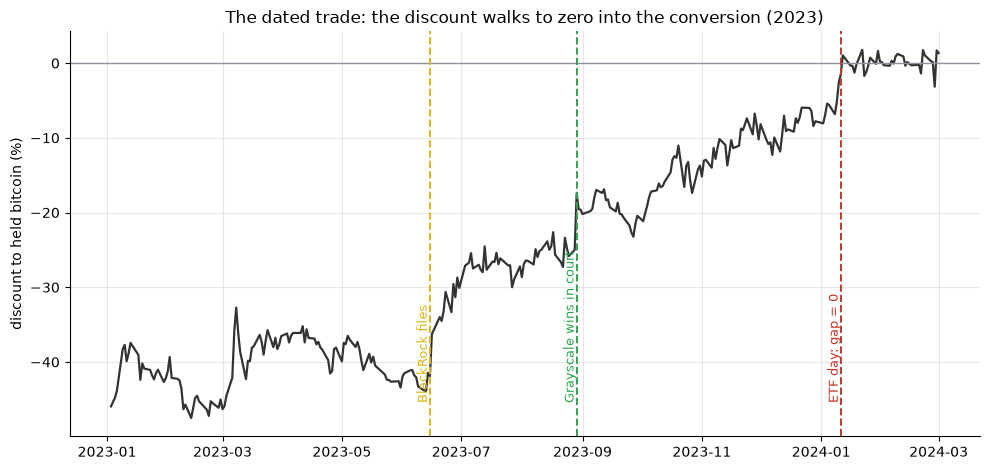

entry (2023-06-16 close): -36.3%   exit (2024-01-11 close): -1.5%


In [3]:
if HAVE_REAL:
    win = DF.loc['2023-01-01':'2024-03-01', 'prem'] * 100
    fig, ax = plt.subplots(figsize=(10.0, 4.8))
    ax.plot(win.index, win.values, lw=1.6, color='#333333')
    ax.axhline(0, c=GREY, lw=1)
    for d, lab, c in [('2023-06-15', 'BlackRock files', AMBER),
                      ('2023-08-29', 'Grayscale wins in court', GREEN),
                      ('2024-01-11', 'ETF day: gap = 0', RED)]:
        ax.axvline(pd.Timestamp(d), c=c, ls='--', lw=1.4)
        ax.annotate(lab, (pd.Timestamp(d), win.min()+2), rotation=90, fontsize=9, color=c, va='bottom', ha='right')
    ax.set_ylabel('discount to held bitcoin (%)')
    ax.set_title('The dated trade: the discount walks to zero into the conversion (2023)')
    plt.tight_layout(); plt.show()
    print(f"entry (2023-06-16 close): {DF['prem'].loc[:'2023-06-16'].iloc[-1]*100:+.1f}%   "
          f"exit (2024-01-11 close): {DF['prem'].loc[:'2024-01-11'].iloc[-1]*100:+.1f}%")
else:
    print('cache missing - triggered trade:', R['conv_trig'])

Entering at the close **one full day after** the filing (no crystal ball, and you forgo the first-day jump) still captured **+43.5 log-points** in 143 trading days — about **+50 % net** of trading costs and the cost of shorting bitcoin. The quants notebook shows this clears the desk's statistical bar (HAC *t* = 2.69) — it wasn't noise, it was a scheduled convergence with two 3.5-sigma news days along the way.

**And the premium era? Who was cashing that?** Not you. Only accredited investors could create shares at fair value — then dump them on the public at +36 % after a lockup. We price that assembly line, month by month:

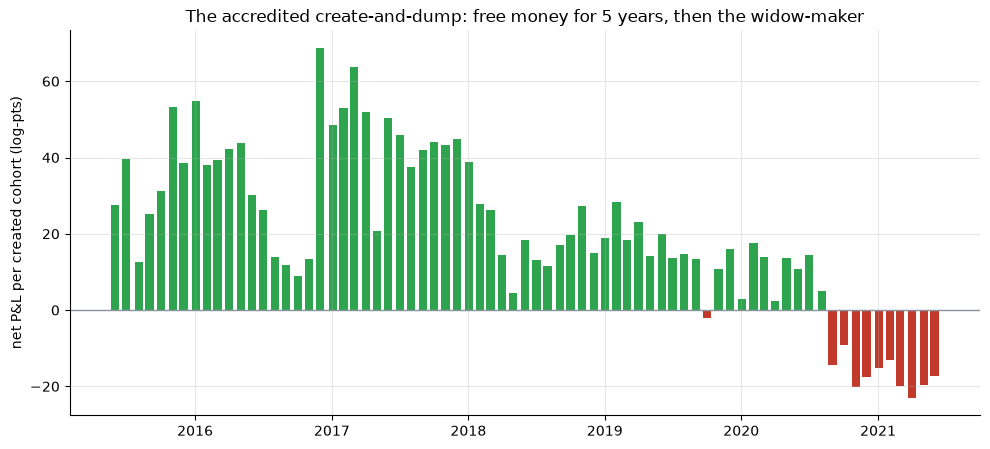

green cohorts: 62 / 73


In [4]:
if HAVE_REAL:
    coh = st.lockup_arb_cohorts(DF)
    fig, ax = plt.subplots(figsize=(10.0, 4.6))
    colors = [GREEN if v > 0 else RED for v in coh['net_log_pct']]
    ax.bar(coh.index, coh['net_log_pct'], width=22, color=colors)
    ax.axhline(0, c=GREY, lw=1)
    ax.set_ylabel('net P&L per created cohort (log-pts)')
    ax.set_title('The accredited create-and-dump: free money for 5 years, then the widow-maker')
    plt.tight_layout(); plt.show()
    print(f"green cohorts: {int((coh['net_log_pct']>0).sum())} / {len(coh)}")
else:
    print('cache missing - cohorts:', R['arb_early_mean'], R['arb_late_mean'])

For five years, every monthly cohort of created shares exited its lockup into a fat premium: **+26 log-points per round**, 98 % hit rate. Hedge funds ran it levered — it looked riskless. Then the premium flipped **mid-lockup** and the same trade delivered **-17** to **-23**: that's the mechanism that helped sink Three Arrows Capital and BlockFi. The public, meanwhile, was never allowed in — retail could only *pay* the premium the insiders were dumping.

## 5 · The verdict

- **Signal — Real.** All three regimes are on the tape exactly as the story says: **+36 %** average premium, **-24 %** average discount (trough -49 %), then **-0.03 %** under the ETF arb. The 2023 convergence passes the honest statistical bar on its no-look-ahead version.
- **Tradability — Fragile.** The one public leg paid ~+50 % net in 7 months with billions of capacity — and then the conversion **deleted the trade forever**. Real, harvested, extinct.
- **Who could harvest? — Mixed.** Premium era: accredited only (until it blew them up). Discount era: anyone with a brokerage. ETF era: no one — the arbitrage became the product.

## 6 · Going further 🚪

- **The general law.** Any fund without redemption can drift arbitrarily far from its assets (closed-end funds have done it for a century). The GBTC cycle is that law run at crypto speed and size.
- **Where it echoes today.** Wrapped-asset premiums didn't die — they moved (MSTR's bitcoin-per-share premium is the operating-company cousin: see [324-bitcoin-treasury](../../324-bitcoin-treasury/)).
- **The meta-lesson.** When a mispricing has a *mechanical* cause, look for the *dated event* that removes the mechanism. That's when a gap is a trade rather than a curiosity.

*Think you've found the next locked-up wrapper trading half off? First question, always: **what exactly forces it back — and when?***